In [ ]:
# Install XGBoost (other libraries are pre-installed in Colab)
!pip install xgboost

# Verify installations
import sklearn
import xgboost
print(f"✓ scikit-learn version: {sklearn.__version__}")
print(f"✓ XGBoost version: {xgboost.__version__}")

✓ scikit-learn version: 1.6.1
✓ XGBoost version: 3.1.1


TELCO CUSTOMER CHURN PREDICTION - COMPREHENSIVE ML ANALYSIS

All libraries imported successfully!

STEP 1: DATA LOADING AND EXPLORATION

Dataset Shape: (7043, 21)
Number of Features: 21
Number of Samples: 7043

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...         

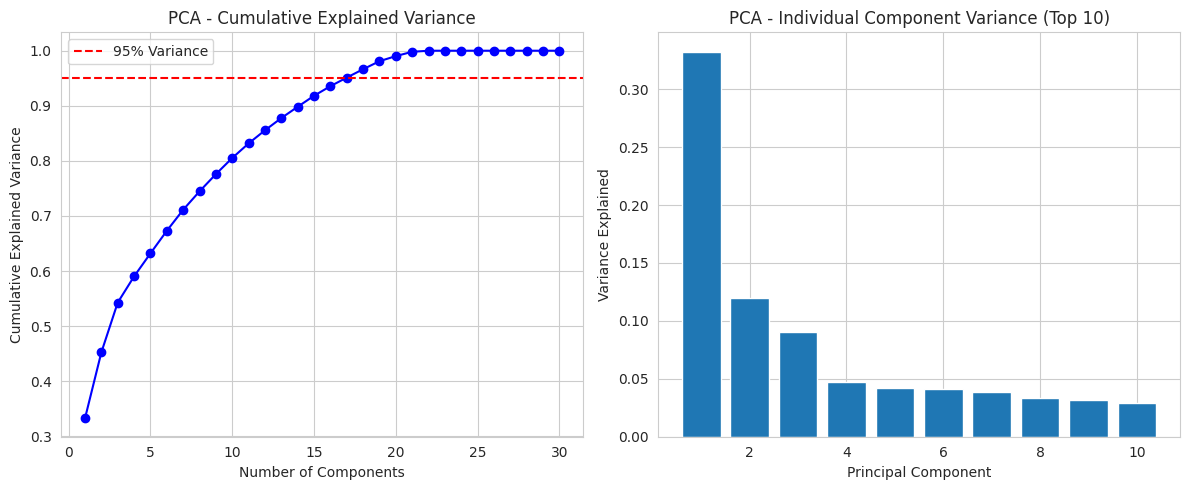


Components needed for 95% variance: 17
Original features: 30
Reduced features: 17

STEP 4: UNSUPERVISED LEARNING - CLUSTERING ANALYSIS

[1] K-Means Clustering
Cluster distribution: [1214 4420]

[2] Hierarchical Clustering
Cluster distribution: [4420 1214]

[3] DBSCAN Clustering
Number of clusters: 7
Number of noise points: 711


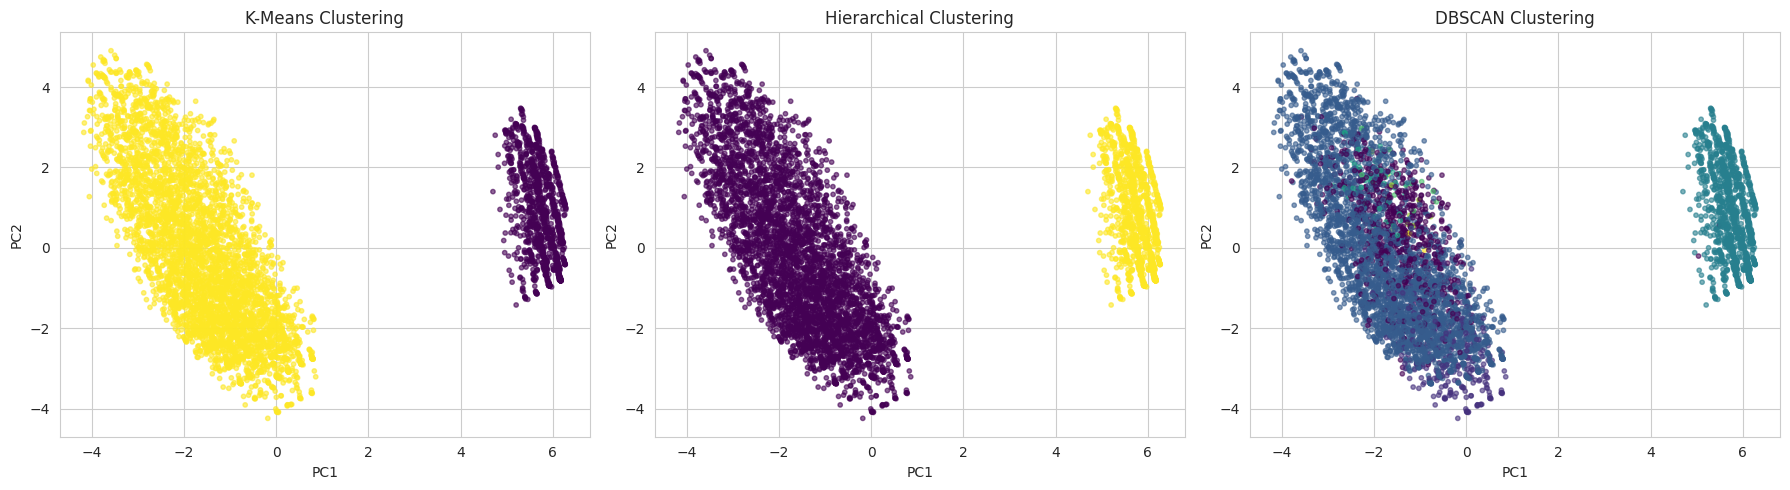


STEP 5: SUPERVISED LEARNING - TRAINING ALL MODELS

Training models...

Training Logistic Regression... ✓ Complete
Training Support Vector Machine... ✓ Complete
Training K-Nearest Neighbors... ✓ Complete
Training Decision Tree... ✓ Complete
Training Naive Bayes... ✓ Complete
Training Random Forest... ✓ Complete
Training AdaBoost... ✓ Complete
Training XGBoost... ✓ Complete
Training Neural Network (MLP)... ✓ Complete
Training Gradient Descent (SGD)... ✓ Complete

MODEL PERFORMANCE COMPARISON

                  Model  Accuracy  Precision   Recall  F1-Score
   Logistic Regression  0.806955   0.658385 0.566845  0.609195
              AdaBoost  0.804826   0.668942 0.524064  0.587706
           Naive Bayes  0.655784   0.426877 0.866310  0.571933
               XGBoost  0.785664   0.609091 0.537433  0.571023
Support Vector Machine  0.792761   0.644366 0.489305  0.556231
         Random Forest  0.787083   0.627586 0.486631  0.548193
         Decision Tree  0.755855   0.539062 0.553476  0.54617

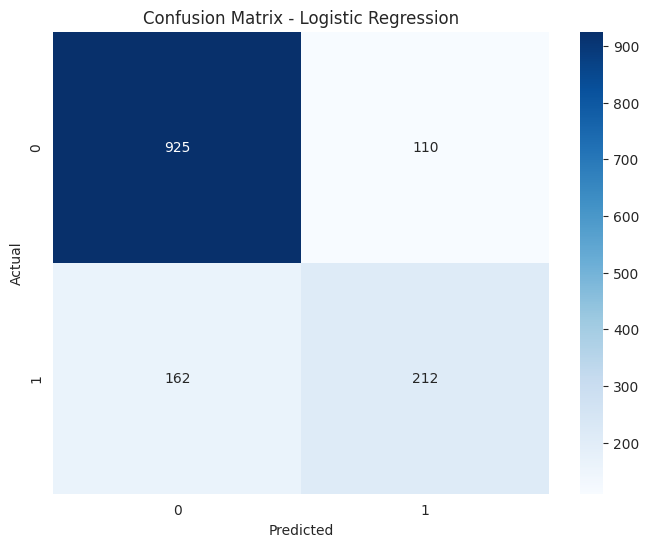


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


STEP 7: COMPREHENSIVE VISUALIZATIONS


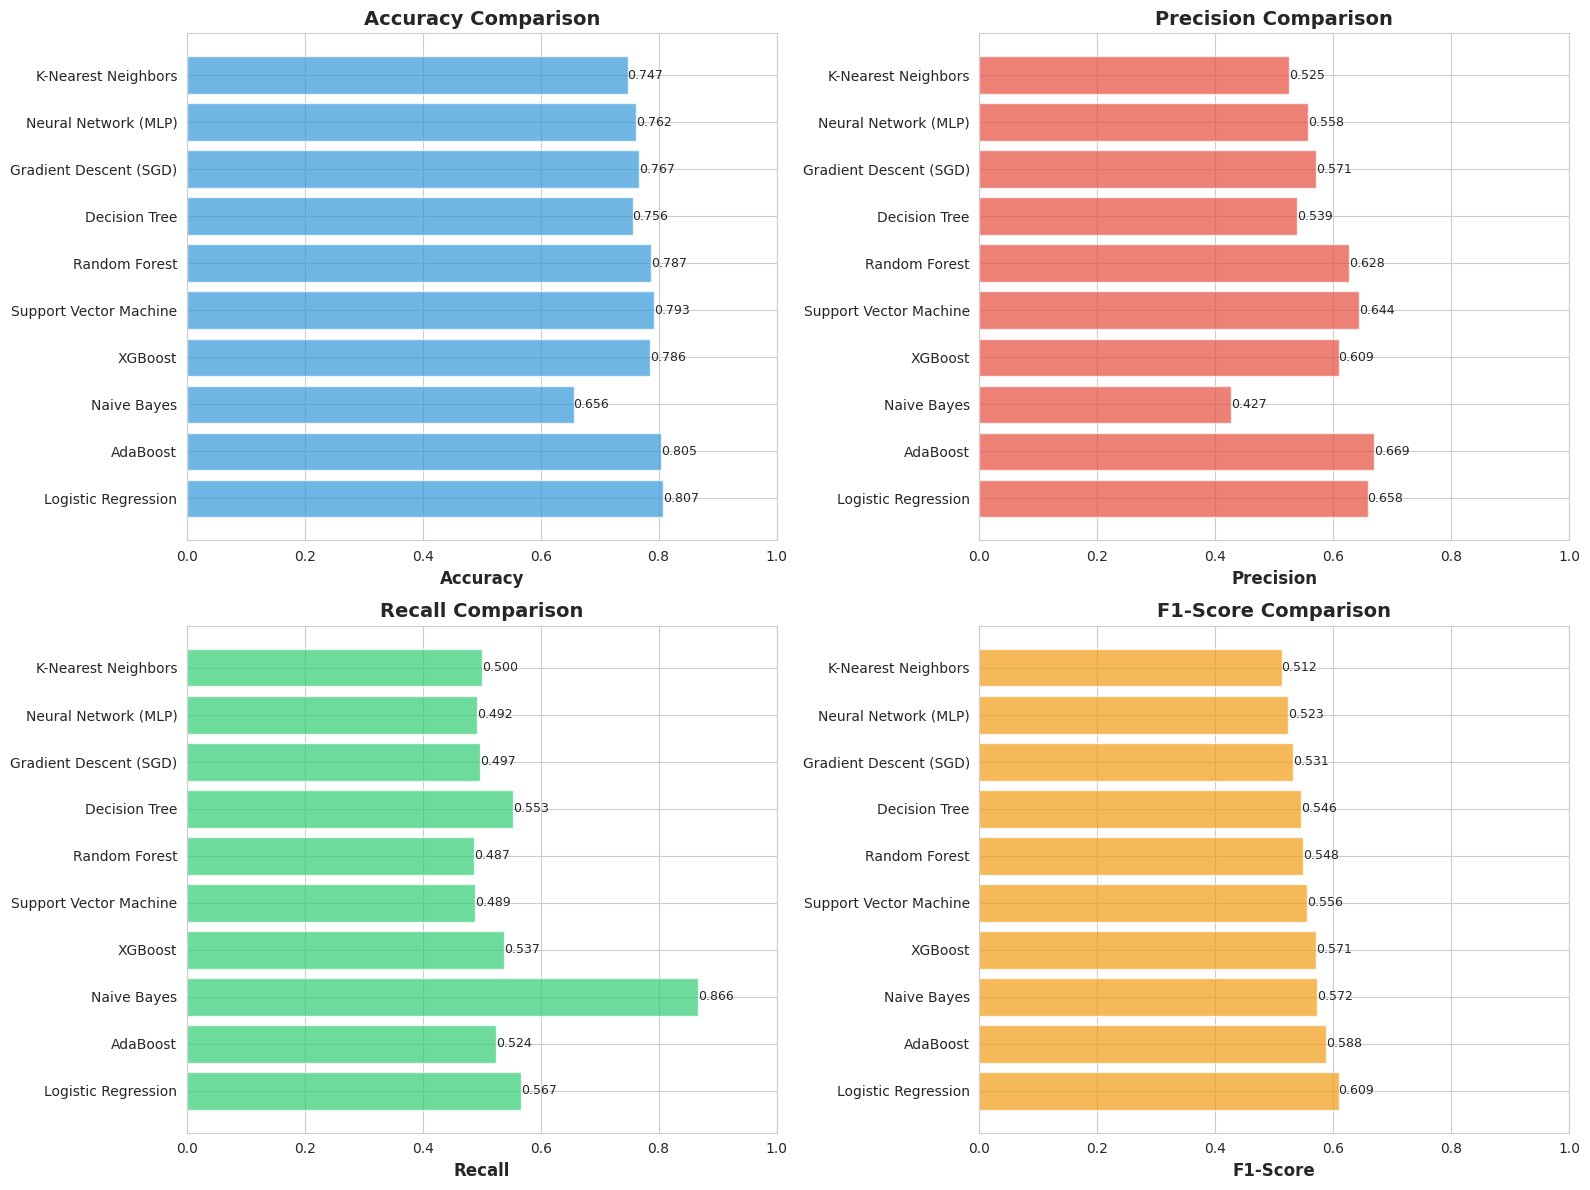

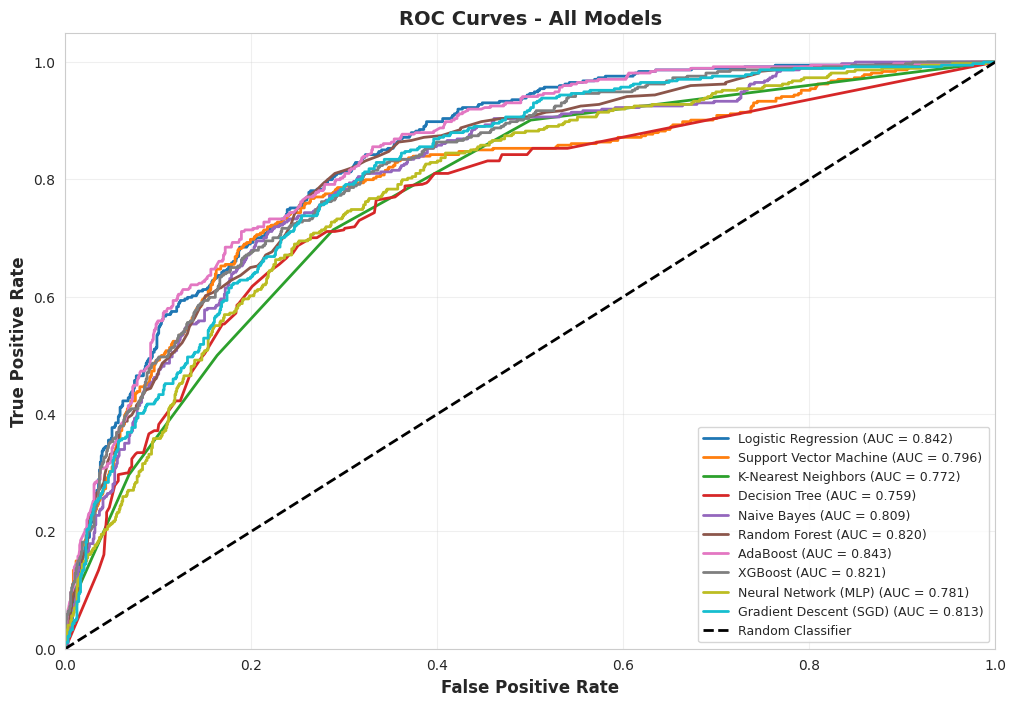


Feature Importance Analysis...


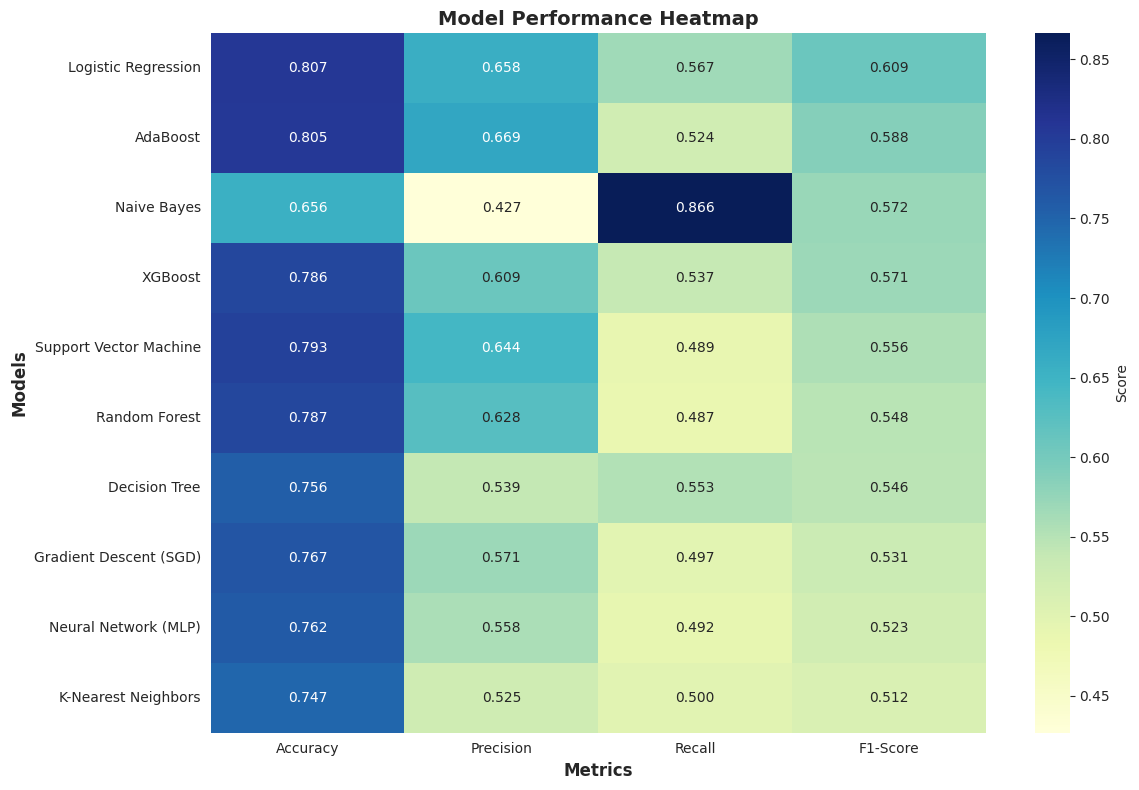

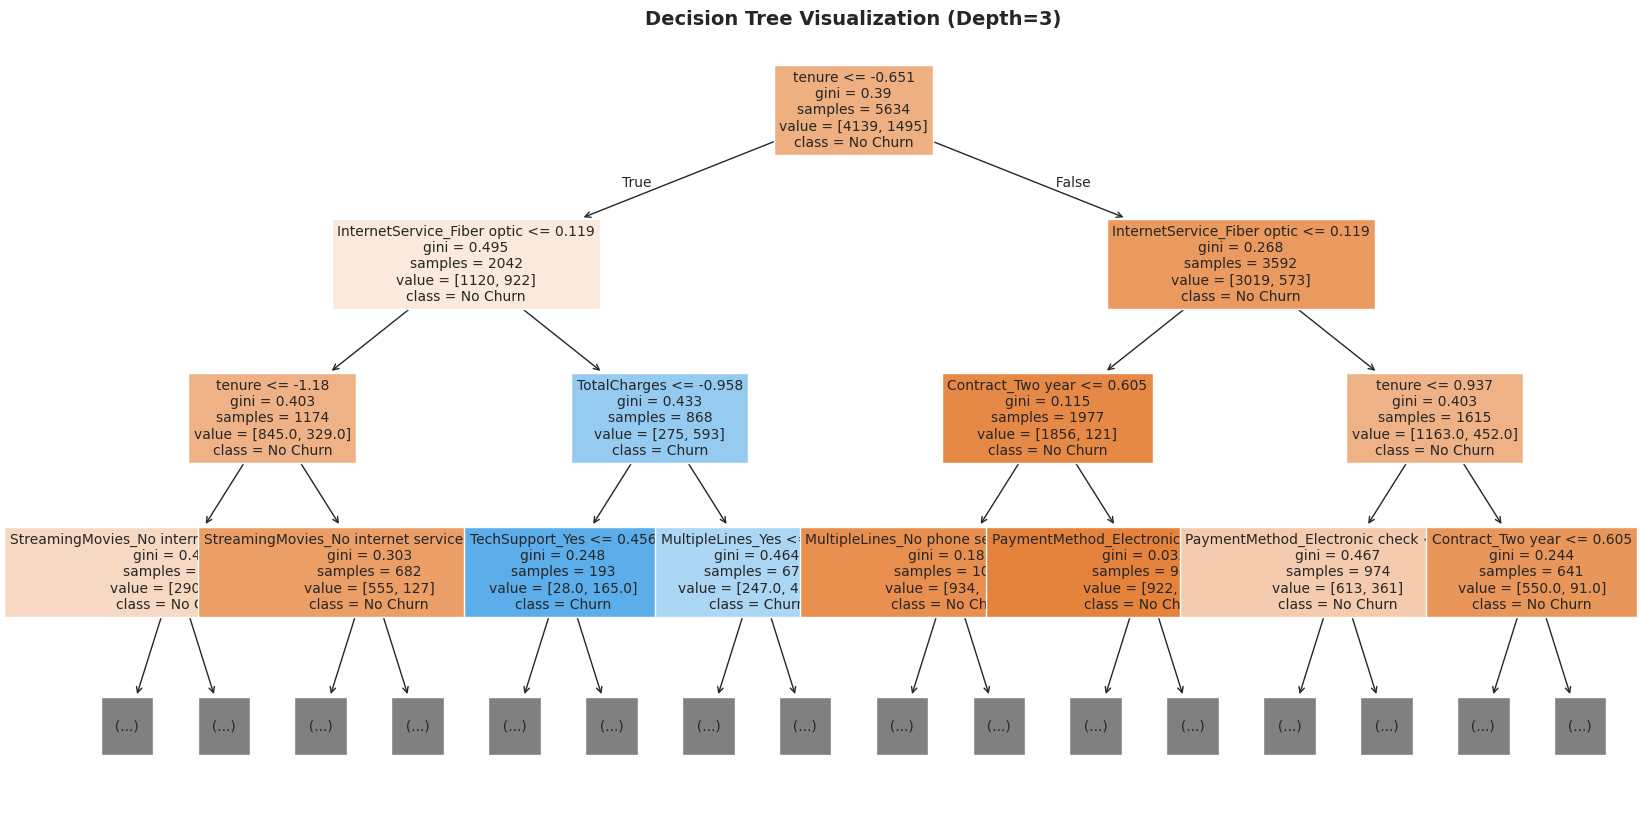


FINAL PROJECT SUMMARY

📊 Dataset: Telco Customer Churn
📈 Total Samples: 7043
🎯 Target Variable: Churn (Binary Classification)
✨ Features (after encoding): 30
🔬 Models Trained: 10

🏆 BEST PERFORMING MODEL
   Model: Logistic Regression
   Accuracy: 0.8070
   Precision: 0.6584
   Recall: 0.5668
   F1-Score: 0.6092

📁 Generated Files:
   ✓ pca_analysis.png
   ✓ clustering_results.png
   ✓ confusion_matrix_best.png
   ✓ model_comparison.png
   ✓ roc_curves.png
   ✓ metrics_heatmap.png
   ✓ decision_tree.png

PROJECT EXECUTION COMPLETED SUCCESSFULLY!

✓ Results saved to 'model_results.csv'


In [ ]:
# ============================================================================
# PART 1: IMPORT LIBRARIES AND SETUP
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

# Supervised Learning Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Neural Network
from sklearn.neural_network import MLPClassifier

# Unsupervised Learning
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

# Gradient Descent
from sklearn.linear_model import SGDClassifier

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("TELCO CUSTOMER CHURN PREDICTION - COMPREHENSIVE ML ANALYSIS")
print("="*80)
print("\nAll libraries imported successfully!")

# ============================================================================
# PART 2: DATA LOADING AND PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND EXPLORATION")
print("="*80)

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1]}")
print(f"Number of Samples: {df.shape[0]}")

print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn'].value_counts()['Yes'] / len(df)) * 100:.2f}%")

# ============================================================================
# PART 3: FEATURE ENGINEERING
# ============================================================================
print("\n" + "="*80)
print("STEP 2: FEATURE ENGINEERING AND PREPROCESSING")
print("="*80)

# Create a copy for processing
df_processed = df.copy()

# Remove customerID as it's not useful for prediction
df_processed = df_processed.drop('customerID', axis=1)

# Handle TotalCharges - convert to numeric
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

# Fill missing values with median
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)

# Convert target variable
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

# Encode binary categorical variables
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_processed[col] = df_processed[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# One-hot encode multi-category variables
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

df_processed = pd.get_dummies(df_processed, columns=multi_cat_cols, drop_first=True)

print(f"\nProcessed Dataset Shape: {df_processed.shape}")
print(f"\nFeature Engineering Complete!")
print(f"Total Features after encoding: {df_processed.shape[1] - 1}")

# Separate features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"\nTraining Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")

# ============================================================================
# PART 4: DIMENSIONALITY REDUCTION (PCA)
# ============================================================================
print("\n" + "="*80)
print("STEP 3: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Apply PCA
pca = PCA()
pca.fit(X_train_scaled)

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('PCA - Individual Component Variance (Top 10)')
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")
print(f"Original features: {X_train_scaled.shape[1]}")

# Create reduced dataset
pca_reduced = PCA(n_components=n_components_95)
X_train_pca = pca_reduced.fit_transform(X_train_scaled)
X_test_pca = pca_reduced.transform(X_test_scaled)

print(f"Reduced features: {X_train_pca.shape[1]}")

# ============================================================================
# PART 5: UNSUPERVISED LEARNING - CLUSTERING
# ============================================================================
print("\n" + "="*80)
print("STEP 4: UNSUPERVISED LEARNING - CLUSTERING ANALYSIS")
print("="*80)

# K-Means Clustering
print("\n[1] K-Means Clustering")
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_pca)
print(f"Cluster distribution: {np.bincount(kmeans_labels)}")

# Hierarchical Clustering
print("\n[2] Hierarchical Clustering")
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_labels = hierarchical.fit_predict(X_train_pca)
print(f"Cluster distribution: {np.bincount(hierarchical_labels)}")

# DBSCAN
print("\n[3] DBSCAN Clustering")
dbscan = DBSCAN(eps=3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_train_pca)
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of noise points: {list(dbscan_labels).count(-1)}")

# Visualize clustering results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=kmeans_labels,
                cmap='viridis', alpha=0.6, s=10)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Plot Hierarchical
axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=hierarchical_labels,
                cmap='viridis', alpha=0.6, s=10)
axes[1].set_title('Hierarchical Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Plot DBSCAN
axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=dbscan_labels,
                cmap='viridis', alpha=0.6, s=10)
axes[2].set_title('DBSCAN Clustering')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PART 6: SUPERVISED LEARNING - MODEL TRAINING
# ============================================================================
print("\n" + "="*80)
print("STEP 5: SUPERVISED LEARNING - TRAINING ALL MODELS")
print("="*80)

# Dictionary to store all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Gradient Descent (SGD)': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
}

# Store results
results = []

print("\nTraining models...\n")

for name, model in models.items():
    print(f"Training {name}...", end=' ')

    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"✓ Complete")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print("\n", results_df.to_string(index=False))

# ============================================================================
# PART 7: DETAILED ANALYSIS OF BEST MODEL
# ============================================================================
print("\n" + "="*80)
print("STEP 6: DETAILED ANALYSIS OF BEST MODEL")
print("="*80)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

# Predictions
y_pred_best = best_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_best.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# ============================================================================
# PART 8: VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 7: COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# 1. Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors[idx], alpha=0.7)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curves for all models
plt.figure(figsize=(12, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Feature Importance (for tree-based models)
print("\nFeature Importance Analysis...")

if 'Random Forest' in best_model_name or 'XGBoost' in best_model_name:
    feature_importance = best_model.feature_importances_
    feature_names = X.columns

    # Get top 15 features
    indices = np.argsort(feature_importance)[-15:]

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), feature_importance[indices], color='teal', alpha=0.7)
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Feature Importance - {best_model_name}',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

# 4. Model Metrics Heatmap
plt.figure(figsize=(12, 8))
metrics_matrix = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Decision Tree Visualization (if Decision Tree is in models)
if 'Decision Tree' in models:
    plt.figure(figsize=(20, 10))
    plot_tree(models['Decision Tree'], filled=True, feature_names=X.columns,
              class_names=['No Churn', 'Churn'], max_depth=3, fontsize=10)
    plt.title('Decision Tree Visualization (Depth=3)', fontsize=14, fontweight='bold')
    plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# PART 9: FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL PROJECT SUMMARY")
print("="*80)

print(f"\n📊 Dataset: Telco Customer Churn")
print(f"📈 Total Samples: {len(df)}")
print(f"🎯 Target Variable: Churn (Binary Classification)")
print(f"✨ Features (after encoding): {X.shape[1]}")
print(f"🔬 Models Trained: {len(models)}")

print(f"\n🏆 BEST PERFORMING MODEL")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

print(f"\n📁 Generated Files:")
print(f"   ✓ pca_analysis.png")
print(f"   ✓ clustering_results.png")
print(f"   ✓ confusion_matrix_best.png")
print(f"   ✓ model_comparison.png")
print(f"   ✓ roc_curves.png")
print(f"   ✓ metrics_heatmap.png")
if 'Random Forest' in best_model_name or 'XGBoost' in best_model_name:
    print(f"   ✓ feature_importance.png")
print(f"   ✓ decision_tree.png")

print("\n" + "="*80)
print("PROJECT EXECUTION COMPLETED SUCCESSFULLY!")
print("="*80)

# Save results to CSV
results_df.to_csv('model_results.csv', index=False)
print("\n✓ Results saved to 'model_results.csv'")


In [ ]:
# Zip all result files
!zip -r results.zip *.png *.csv

# Download the zip file
from google.colab import files
files.download('results.zip')

  adding: clustering_results.png (deflated 2%)
  adding: confusion_matrix_best.png (deflated 26%)
  adding: decision_tree.png (deflated 10%)
  adding: metrics_heatmap.png (deflated 16%)
  adding: model_comparison.png (deflated 26%)
  adding: pca_analysis.png (deflated 18%)
  adding: roc_curves.png (deflated 9%)
  adding: model_results.csv (deflated 42%)
  adding: WA_Fn-UseC_-Telco-Customer-Churn.csv (deflated 83%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>